# 09 — Rebalance Frequency Sensitivity

Compare strategy performance and turnover across rebalance frequencies of
**1, 2, 5, 10 trading days** and **weekly**.

The signal and weight construction are unchanged. We only vary *how often* the
existing daily target weights are refreshed, using
`src.portfolio.rebalance.apply_rebalance_frequency`. Weights are held constant
between rebalance dates. `rebalance_frequency=1` reproduces the existing
daily-rebalance behaviour exactly.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parents[2]
sys.path.append(str(PROJECT_ROOT))

from src.pipelines.cross_sectional import run_market_alpha_pipeline
from src.portfolio.rebalance import apply_rebalance_frequency, weights_to_wide
from src.analysis.turnover import compute_turnover, summarize_turnover
from src.risk.allocation import compare_base_vs_dd_overlay
from src.utils.metrics import sharpe_ratio, max_drawdown, annualized_return

print(PROJECT_ROOT)

/Users/rawls/quant-lab


## 1. Build the panel

Load the cached NIFTY50 OHLCV data (same schema as `download_market_data`) and
run the standard cross-sectional alpha pipeline to produce the daily weight
panel. To pull fresh data instead, use
`download_market_data(MARKET_CONFIGS["india"])`.

In [2]:
import glob

data = {}
for fpath in sorted(glob.glob(str(PROJECT_ROOT / "data/raw/NIFTY50/*.csv"))):
    d = pd.read_csv(fpath)
    d["Date"] = pd.to_datetime(d["Date"])
    d = d.set_index("Date").sort_index()
    data[d["ticker"].iloc[0]] = d

panel = run_market_alpha_pipeline(data)
print(f"{len(data)} tickers | {panel['Date'].nunique()} trading dates | {len(panel)} rows")

20 tickers | 2809 trading dates | 56180 rows


## 2. Sweep rebalance frequencies

For each frequency we hold the daily target weights constant between rebalance
dates, then route the resulting weights through the *existing* return engine
(`compare_base_vs_dd_overlay`) and turnover utilities. Nothing about signal
generation or weight construction changes.

In [3]:
frequencies = [1, 2, 5, 10, "weekly"]

rows = []
equity_curves = {}

for freq in frequencies:
    panel_f = apply_rebalance_frequency(panel, freq)

    compare_df, base_ret, dd_ret, dd_exposure = compare_base_vs_dd_overlay(panel_f)

    wide_weights = weights_to_wide(panel_f)
    turnover = compute_turnover(wide_weights)
    tsum = summarize_turnover(turnover)

    equity = (1 + base_ret).cumprod()
    equity_curves[str(freq)] = equity

    rows.append({
        "Rebalance": str(freq),
        "Sharpe": sharpe_ratio(base_ret),
        "CAGR": annualized_return(base_ret),
        "MDD": max_drawdown(equity),
        "Avg Turnover": tsum["mean"],
        "Median Turnover": tsum["median"],
        "Max Turnover": tsum["max"],
        "Turnover p95": tsum["p95"],
    })

results_df = pd.DataFrame(rows).round(4)
results_df

,Rebalance,Sharpe,CAGR,MDD,Avg Turnover,Median Turnover,Max Turnover,Turnover p95
0,1,1.8382,0.4446,-0.4079,0.3548,0.3333,0.8889,0.5556
1,2,1.9068,0.4616,-0.3883,0.2462,0.0000,1.0000,0.6667
2,5,1.4458,0.3367,-0.4828,0.1561,0.0000,1.0000,0.8889
3,10,0.9440,0.1904,-0.6157,0.0772,0.0000,1.0000,0.7778
4,weekly,1.2383,0.2716,-0.4462,0.1598,0.0000,1.0000,0.8889


## 3. Visualise turnover vs. performance

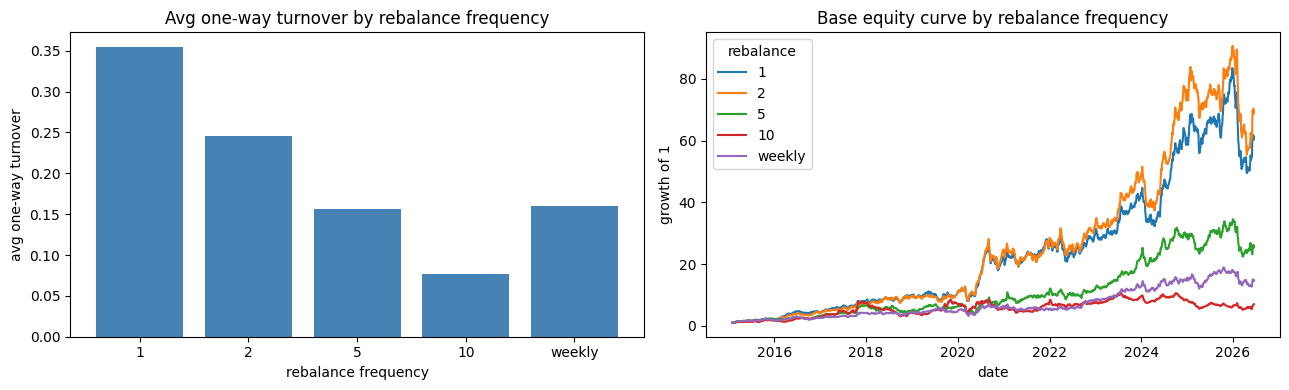

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(results_df["Rebalance"], results_df["Avg Turnover"], color="steelblue")
axes[0].set_title("Avg one-way turnover by rebalance frequency")
axes[0].set_xlabel("rebalance frequency")
axes[0].set_ylabel("avg one-way turnover")

for name, equity in equity_curves.items():
    axes[1].plot(equity.index, equity.values, label=name)
axes[1].set_title("Base equity curve by rebalance frequency")
axes[1].set_xlabel("date")
axes[1].set_ylabel("growth of 1")
axes[1].legend(title="rebalance")

plt.tight_layout()
plt.show()

## 4. Notes

- `rebalance_frequency=1` is the existing daily strategy (identity check: weights
  are returned unchanged).
- Lower rebalance frequency reduces turnover roughly proportionally, while
  performance (Sharpe / CAGR / MDD) shows the cost/benefit trade-off.
- Turnover here measures **actual rebalancing trades**: weights change only on
  rebalance dates and are carried forward in between, so off-rebalance daily
  turnover is zero by construction.
- This notebook does not apply transaction costs; pair the turnover column with a
  per-unit cost assumption to estimate net impact.